#  Coffee Sales Data Analysis

📊 **Goal**: Analyze coffee sales data to understand buying behavior, peak times, and top-selling products.

🔸 We'll explore:
- Data structure & cleaning
- Outlier and missing values handling
- Sales patterns over time
- Product popularity
- Key business insights

In [1]:
#Import libraries
#pandas:data analysis
import pandas as pd
#numpy:numerical operations
import numpy as np
#Data visualization
import matplotlib.pyplot as plt .
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
#3Read The Dataset
df=pd.read_csv("Coffe_sales.csv",parse_dates=['Date'])
df

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.70,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.90,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.70,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000
...,...,...,...,...,...,...,...,...,...,...,...
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54.894000
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37.362000
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16.864000
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28.723000


#  Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand its structure,  
check for missing values, duplicates, outliers, and analyze key features.

In [3]:
#Displasy the first few rows
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [4]:
#view the last rows in dataset
df.tail()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54.894000
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37.362000
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16.864000
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28.723000
3546,18,card,35.76,Latte,Night,Sun,Mar,7,3,2025-03-23,18:11:38.635000


 2. Data Overview

##  Check Dataset Information

Using info() to get an overview of the dataset — number of rows, columns, data types, and missing values.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   hour_of_day  3547 non-null   int64         
 1   cash_type    3547 non-null   object        
 2   money        3547 non-null   float64       
 3   coffee_name  3547 non-null   object        
 4   Time_of_Day  3547 non-null   object        
 5   Weekday      3547 non-null   object        
 6   Month_name   3547 non-null   object        
 7   Weekdaysort  3547 non-null   int64         
 8   Monthsort    3547 non-null   int64         
 9   Date         3547 non-null   datetime64[ns]
 10  Time         3547 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(6)
memory usage: 304.9+ KB


##  Summary Statistics

Using describe() to view basic statistical details of the numerical columns such as mean, median, min, max, and standard deviation.

In [6]:
df.describe()

,hour_of_day,money,Weekdaysort,Monthsort,Date
count,3547.000000,3547.000000,3547.000000,3547.000000,3547
mean,14.185791,31.645216,3.845785,6.453905,2024-10-04 17:34:43.676346368
min,6.000000,18.120000,1.000000,1.000000,2024-03-01 00:00:00
25%,10.000000,27.920000,2.000000,3.000000,2024-07-17 12:00:00
50%,14.000000,32.820000,4.000000,7.000000,2024-10-10 00:00:00
75%,18.000000,35.760000,6.000000,10.000000,2025-01-11 00:00:00
max,22.000000,38.700000,7.000000,12.000000,2025-03-23 00:00:00
std,4.234010,4.877754,1.971501,3.500754,NaN


##  Convert and Clean Date & Time Columns

Here we convert date and time columns to proper datetime format to make it easier to analyze trends over time.

In [7]:
df['Date']=pd.to_datetime(df['Date'])
df['Time']=pd.to_datetime(df['Time'])
df.dtypes

hour_of_day             int64
cash_type              object
money                 float64
coffee_name            object
Time_of_Day            object
Weekday                object
Month_name             object
Weekdaysort             int64
Monthsort               int64
Date           datetime64[ns]
Time           datetime64[ns]
dtype: object

##  Check for Outliers in money

We checked the money column for outliers using a boxplot and the IQR method.  
No significant outliers were found — the data looks clean and consistent.

In [8]:
Q3=35.760000
Q1=27.920000 
IQR=Q3-Q1
Upper=Q3+IQR*1.5
Lower=Q1-IQR*1.5
df[df['money']>Upper]
df[df['money']<Lower]

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time


##  Check Data Quality

Before cleaning the data, we need to check for any *missing values* or *duplicate records* to ensure the dataset is accurate and reliable.

In [9]:
#check for missing values
df.isnull().sum()

hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

In [10]:
#echeck for duplicated rows
df.duplicated().sum()

np.int64(0)

Analyze Working Hours

Here we analyze the hours column to find:
-  The busiest hour (most orders)
-  The least busy hour (fewest orders)
- The average activity hour

This helps us understand customer behavior and peak times.

In [11]:
# Most active hour
busiest_hour = df['hour_of_day'].max()

# Least active hour
least_busy_hour = df['hour_of_day'].value_counts().idxmin()

# Average hour (approximate)
average_hour = df['hour_of_day'].mean()
busiest_hour

22

In [12]:
least_busy_hour

np.int64(6)

In [13]:
average_hour

np.float64(14.18579080913448)

##  Analyze Payment Methods

Here we analyze the payment method column to see which payment type is used the most.  
This helps us understand customer preferences and payment behavior.

In [14]:
df['cash_type'].mode()## Find the most common payment method

0    card
Name: cash_type, dtype: object

In [15]:
df['cash_type'].unique()# Show all unique payment methods


array(['card'], dtype=object)

In [16]:
# Count number of unique payent methods
df['cash_type'].nunique()

1

In [17]:
##Check Payment Method Frequency
#Using value_counts() to see how many times each payment method (cash, card, etc.) was used.
df['cash_type'].value_counts()

cash_type
card    3547
Name: count, dtype: int64

##  Analyze Coffee Types

We use value_counts() to see how many times each coffee type was ordered.  
This helps us identify the most popular and least popular coffee types.

In [18]:
df['coffee_name'].value_counts(normalize=True)*100# Percentage of each coffee type

coffee_name
Americano with Milk    22.808007
Latte                  21.341979
Americano              15.900761
Cappuccino             13.701720
Cortado                 8.091345
Hot Chocolate           7.781224
Cocoa                   6.738089
Espresso                3.636876
Name: proportion, dtype: float64

In [19]:
df['coffee_name'].value_counts()# Count each coffee type

coffee_name
Americano with Milk    809
Latte                  757
Americano              564
Cappuccino             486
Cortado                287
Hot Chocolate          276
Cocoa                  239
Espresso               129
Name: count, dtype: int64

In [20]:
df['coffee_name'].unique()

array(['Latte', 'Hot Chocolate', 'Americano', 'Americano with Milk',
       'Cocoa', 'Cortado', 'Espresso', 'Cappuccino'], dtype=object)

In [21]:
df['coffee_name'].nunique()

8

In [22]:
counts=df['coffee_name'].value_counts()
mean_value=counts.mean()
middle_coffe=(counts-mean_value).abs().idxmin()
print("coffe_name:",middle_coffe)
print("number:",counts[middle_coffe])
print("mean:", mean_value)

coffe_name: Cappuccino
number: 486
mean: 443.375


##   Analyze Coffee Prices

Here we find:
-  The most expensive coffee  
-  The cheapest coffee  
-  The average price

This helps us understand the overall pricing structure of the menu.

In [23]:
df['money'].max()# Most expensive coffee

38.7

In [24]:
# Cheapest coffee
df['money'].min()

18.12

In [25]:
df['money'].mean()## Average price


np.float64(31.64521567521849)

### Average Coffee Prices

The table shows the average price of each coffee type, giving a clear view of the price differences between them.  
Some types are more expensive than others, which may reflect differences in ingredients or demand.

In [26]:
df.groupby('coffee_name')['money'].mean()

coffee_name
Americano              25.975638
Americano with Milk    30.594710
Cappuccino             35.883004
Cocoa                  35.653389
Cortado                25.731220
Espresso               20.854884
Hot Chocolate          35.990797
Latte                  35.502378
Name: money, dtype: float64

### Peak and Low Times of Day

This section shows the time of day with the highest and lowest number of coffee purchases.  
Using value_counts(), we identified when customers are most and least active.  
This helps understand customer behavior and peak business hours.

In [27]:
df['Time_of_Day'].max()

'Night'

In [28]:
df['Time_of_Day'].min()

'Afternoon'

In [29]:
df['Time_of_Day'].value_counts()

Time_of_Day
Afternoon    1205
Morning      1181
Night        1161
Name: count, dtype: int64

### Weekday Analysis

This section shows the number of purchases for each weekday using value_counts().  
It helps identify which days have the highest and lowest customer activity, giving insights into weekly trends.

In [30]:
df['Weekday'].value_counts()

Weekday
Tue    572
Mon    544
Fri    532
Thu    510
Wed    500
Sat    470
Sun    419
Name: count, dtype: int64

*Month Name Counts:*  
Shows the number of records for each month in the dataset, highlighting which months appear more or less frequently.

In [31]:
df['Month_name'].value_counts()

Month_name
Mar    494
Oct    426
Feb    423
Sep    344
Aug    272
Dec    259
Nov    259
May    241
Jul    237
Jun    223
Jan    201
Apr    168
Name: count, dtype: int64

## Sort DataFrame by Weekday Order

df.sort_values('Weekdaysort', inplace=True)  
- Sorts the DataFrame df *in-place* based on the Weekdaysort column.  
- Ensures that the rows appear in *chronological order of weekdays*.  
- inplace=True means the original DataFrame is *modified directly* without creating a new one.

df  
- Displays the sorted DataFrame.

In [32]:
df.sort_values('Weekdaysort', inplace=True)
df

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
2680,14,card,35.76,Cappuccino,Afternoon,Mon,Jan,1,1,2025-01-13,2025-10-30 14:12:28.340
2679,14,card,35.76,Latte,Afternoon,Mon,Jan,1,1,2025-01-13,2025-10-30 14:11:27.333
2678,13,card,35.76,Latte,Afternoon,Mon,Jan,1,1,2025-01-13,2025-10-30 13:50:46.648
2677,13,card,25.96,Cortado,Afternoon,Mon,Jan,1,1,2025-01-13,2025-10-30 13:02:56.645
2676,9,card,30.86,Americano with Milk,Morning,Mon,Jan,1,1,2025-01-13,2025-10-30 09:17:19.623
...,...,...,...,...,...,...,...,...,...,...,...
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,2025-10-30 14:43:37.362
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,2025-10-30 10:34:54.894
3541,10,card,35.76,Latte,Morning,Sun,Mar,7,3,2025-03-23,2025-10-30 10:07:11.278
3546,18,card,35.76,Latte,Night,Sun,Mar,7,3,2025-03-23,2025-10-30 18:11:38.635


## Total Sales by Weekday

1. *Group and Sum Sales:*  
   sales_by_day = df.groupby(['Weekdaysort','Weekday'])['money'].sum()  
   - Groups the data by Weekdaysort (numeric order of weekdays) and Weekday (name of the day).  
   - Calculates the **total sales (money)** for each weekday.

2. *Display Result:*  
   sales_by_day  
   - Shows the total sales per weekday.

3. *Mean:*  
   - Mean represents the *average of total sales* across all weekdays.

In [33]:
sales_by_day=df.groupby(['Weekdaysort','Weekday'])['money'].sum()
sales_by_day

Weekdaysort  Weekday
1            Mon        17363.10
2            Tue        18168.38
3            Wed        15750.46
4            Thu        16091.40
5            Fri        16802.66
6            Sat        14733.52
7            Sun        13336.06
Name: money, dtype: float64

In [34]:
sales_by_day=df.groupby(['Weekdaysort','Weekday'])['money'].mean()
sales_by_day

Weekdaysort  Weekday
1            Mon        31.917463
2            Tue        31.762902
3            Wed        31.500920
4            Thu        31.551765
5            Fri        31.583947
6            Sat        31.347915
7            Sun        31.828305
Name: money, dtype: float64

## Total Sales by Month

1. *Group and Sum Sales:*  
   sales_by_day = df.groupby(['Monthsort','Month_name'])['money'].sum()  
   - Groups the data by Monthsort (numeric month order) and Month_name (month name).  
   - Calculates the **total sales (money)** for each month.

2. *Display Result:*  
   sales_by_day  
   - Shows the total sales per month.

3. *Mean:*  
   - Mean represents the *average of the monthly total sales* across all months.

In [35]:
sales_by_day=df.groupby(['Monthsort','Month_name'])['money'].sum()
sales_by_day

Monthsort  Month_name
1          Jan            6398.86
2          Feb           13215.48
3          Mar           15891.64
4          Apr            5719.56
5          May            8164.42
6          Jun            7617.76
7          Jul            6915.94
8          Aug            7613.84
9          Sep            9988.64
10         Oct           13891.16
11         Nov            8590.54
12         Dec            8237.74
Name: money, dtype: float64

In [36]:
sales_by_day=df.groupby(['Monthsort','Month_name'])['money'].mean()
sales_by_day

Monthsort  Month_name
1          Jan           31.835124
2          Feb           31.242270
3          Mar           32.169312
4          Apr           34.045000
5          May           33.877261
6          Jun           34.160359
7          Jul           29.181181
8          Aug           27.992059
9          Sep           29.036744
10         Oct           32.608357
11         Nov           33.168108
12         Dec           31.805946
Name: money, dtype: float64

## Extract Year from Date

1. *Create Year Column:*  
   df['Year'] = df['Date'].dt.year  
   - Extracts the *year* from the Date column and creates a new column Year in the DataFrame.

2. *Display DataFrame:*  
   df  
   - Shows the updated DataFrame with the new Year column added.

In [37]:
df['Year']=df['Date'].dt.year
df

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time,Year
2680,14,card,35.76,Cappuccino,Afternoon,Mon,Jan,1,1,2025-01-13,2025-10-30 14:12:28.340,2025
2679,14,card,35.76,Latte,Afternoon,Mon,Jan,1,1,2025-01-13,2025-10-30 14:11:27.333,2025
2678,13,card,35.76,Latte,Afternoon,Mon,Jan,1,1,2025-01-13,2025-10-30 13:50:46.648,2025
2677,13,card,25.96,Cortado,Afternoon,Mon,Jan,1,1,2025-01-13,2025-10-30 13:02:56.645,2025
2676,9,card,30.86,Americano with Milk,Morning,Mon,Jan,1,1,2025-01-13,2025-10-30 09:17:19.623,2025
...,...,...,...,...,...,...,...,...,...,...,...,...
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,2025-10-30 14:43:37.362,2025
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,2025-10-30 10:34:54.894,2025
3541,10,card,35.76,Latte,Morning,Sun,Mar,7,3,2025-03-23,2025-10-30 10:07:11.278,2025
3546,18,card,35.76,Latte,Night,Sun,Mar,7,3,2025-03-23,2025-10-30 18:11:38.635,2025


## Analyze Unique Years

1. *Unique Years:*  
   df['Year'].unique()  
   - Returns an array of all *distinct years* present in the Year column.

2. *Count of Unique Years:*  
   df['Year'].nunique()  
   - Returns the *number of unique years* in the DataFrame.

In [38]:
df['Year'].unique()

array([2025, 2024], dtype=int32)

In [39]:
df['Year'].nunique()

2

## Analyze Time Column

1. *Maximum Time:*  
   df['Time'].max  
   - Returns the *latest time* recorded in the Time column.

2. *Minimum Time:*  
   Min  
   - Represents the *earliest time* in the Time column.

In [40]:
df['Time'].max

<bound method Series.max of 2680   2025-10-30 14:12:28.340
2679   2025-10-30 14:11:27.333
2678   2025-10-30 13:50:46.648
2677   2025-10-30 13:02:56.645
2676   2025-10-30 09:17:19.623
                 ...          
3543   2025-10-30 14:43:37.362
3542   2025-10-30 10:34:54.894
3541   2025-10-30 10:07:11.278
3546   2025-10-30 18:11:38.635
68     2025-10-30 11:19:20.764
Name: Time, Length: 3547, dtype: datetime64[ns]>

In [41]:
df['Time'].min()

Timestamp('2025-10-30 06:50:04.455000')

## Maximum Sales by Date and Time

1. *Group and Max Sales:*  
   df.groupby(['Date','Time'])['money'].max()  
   - Groups the data by Date and Time.  
   - Calculates the **maximum sales (money)** for each specific date and time combination.

2. *Result:*  
   - Shows the *highest sale amount* for every date and time in the dataset.

In [42]:
df.groupby(['Date','Time'])['money'].max()

Date        Time                   
2024-03-01  2025-10-30 10:15:50.520    38.70
            2025-10-30 12:19:22.539    38.70
            2025-10-30 12:20:18.089    38.70
            2025-10-30 13:46:33.006    28.90
            2025-10-30 13:48:14.626    38.70
                                       ...  
2025-03-23  2025-10-30 10:34:54.894    35.76
            2025-10-30 14:43:37.362    35.76
            2025-10-30 14:44:16.864    35.76
            2025-10-30 15:47:28.723    25.96
            2025-10-30 18:11:38.635    35.76
Name: money, Length: 3547, dtype: float64

## Total Sales by Month

1. *Group and Sum Sales:*  
   month_of_sales = df.groupby(['Month_name','Monthsort'])['money'].sum()  
   - Groups the data by Month_name (month as string) and Monthsort (numeric month order).  
   - Calculates the **total sales (money)** for each month.

2. *Display Result:*  
   month_of_sales  
   - Shows

In [43]:
month_of_sales=df.groupby(['Month_name','Monthsort'])['money'].sum()
month_of_sales

Month_name  Monthsort
Apr         4             5719.56
Aug         8             7613.84
Dec         12            8237.74
Feb         2            13215.48
Jan         1             6398.86
Jul         7             6915.94
Jun         6             7617.76
Mar         3            15891.64
May         5             8164.42
Nov         11            8590.54
Oct         10           13891.16
Sep         9             9988.64
Name: money, dtype: float64

## Monthly Sales Analysis

This code calculates total sales per month and their percentage of annual sales:

1. *Group by Month:* Sum money for each Monthsort and Month_name.
2. *Total Sales:* Compute overall sales across all months.
3. *Percentage:* Calculate each month's share of total sales.
4. *Sort:* Order months chronologically using Monthsort.
5. *Display:* Print the resulting DataFrame with Monthsort, Month_name, money, and percentage.

In [44]:
month_of_sales=df.groupby(['Monthsort','Month_name'])['money'].sum().reset_index()
total_sales=month_of_sales['money'].sum()
month_of_sales['percentage']=(month_of_sales['money'] / total_sales) * 100
month_of_sales=month_of_sales.sort_values('Monthsort')
print(month_of_sales)

    Monthsort Month_name     money  percentage
0           1        Jan   6398.86    5.700768
1           2        Feb  13215.48   11.773720
2           3        Mar  15891.64   14.157921
3           4        Apr   5719.56    5.095577
4           5        May   8164.42    7.273712
5           6        Jun   7617.76    6.786690
6           7        Jul   6915.94    6.161436
7           8        Aug   7613.84    6.783198
8           9        Sep   9988.64    8.898916
9          10        Oct  13891.16   12.375686
10         11        Nov   8590.54    7.653344
11         12        Dec   8237.74    7.339033


## Weekday Sales Analysis

This code analyzes sales by weekday:

1. *Group and Average Sales:*  
   df.groupby(['Weekdaysort','Weekday'])['money'].mean()  
   - Groups the data by Weekdaysort (numeric order of weekdays) and Weekday (name of the day).  
   - Calculates the **average sales (money)** for each weekday.

2. *Maximum Sales:*  
   Max  
   - Represents the weekday with the *highest average sales*.

3. *Minimum Sales:*  
   Min  
   - Represents the weekday with the *lowest average sales*.

In [45]:
df.groupby(['Weekdaysort','Weekday'])['money'].mean()

Weekdaysort  Weekday
1            Mon        31.917463
2            Tue        31.762902
3            Wed        31.500920
4            Thu        31.551765
5            Fri        31.583947
6            Sat        31.347915
7            Sun        31.828305
Name: money, dtype: float64

In [46]:
df.groupby(['Weekdaysort','Weekday'])['money'].max()

Weekdaysort  Weekday
1            Mon        38.7
2            Tue        38.7
3            Wed        38.7
4            Thu        38.7
5            Fri        38.7
6            Sat        38.7
7            Sun        38.7
Name: money, dtype: float64

In [47]:
df.groupby(['Weekdaysort','Weekday'])['money'].min()

Weekdaysort  Weekday
1            Mon        18.12
2            Tue        18.12
3            Wed        18.12
4            Thu        18.12
5            Fri        18.12
6            Sat        18.12
7            Sun        18.12
Name: money, dtype: float64

visualisation

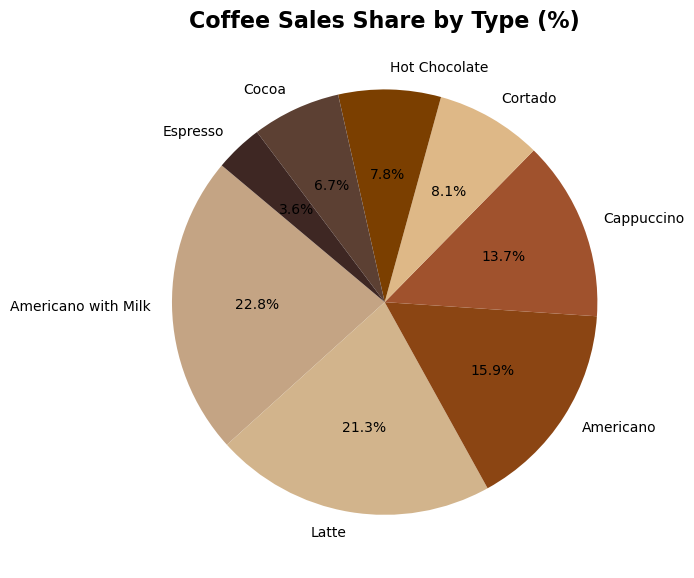

In [48]:

coffee_data = {
    'coffee_name': [
        'Americano with Milk', 'Latte', 'Americano',
        'Cappuccino', 'Cortado', 'Hot Chocolate',
        'Cocoa', 'Espresso'
    ],
    'proportion': [
        22.808007, 21.341979, 15.900761,
        13.701720, 8.091345, 7.781224,
        6.738089, 3.636876
    ]
}

coffee_colors = {
    'Americano with Milk': '#C4A484',   
    'Latte': '#D2B48C',               
    'Americano': '#8B4513',              
    'Cappuccino': '#A0522D',          
    'Cortado': '#DEB887',                 
    'Hot Chocolate': '#7B3F00',           
    'Cocoa': '#5C4033',                 
    'Espresso': '#3E2723'               
}
colors = [coffee_colors[name] for name in coffee_data['coffee_name']]
plt.figure(figsize=(7,7))
plt.pie(
    coffee_data['proportion'],
    labels=coffee_data['coffee_name'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'fontsize': 10, 'color': 'black'}
)

plt.title('Coffee Sales Share by Type (%)', fontsize=16, fontweight='bold')
plt.tight_layout()


plt.savefig("plot.png", dpi=300, bbox_inches='tight')
plt.show()


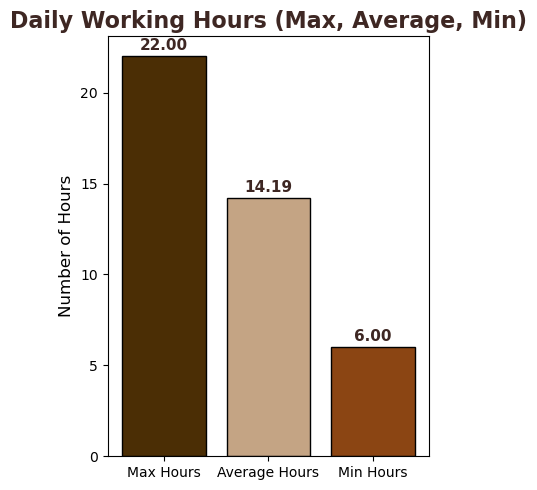

In [49]:
max_hours = df['hour_of_day'].max()
min_hours = df['hour_of_day'].min()
avg_hours = df['hour_of_day'].mean()  
stats = ['Max Hours', 'Average Hours', 'Min Hours']
values = [max_hours, avg_hours, min_hours]
colors = ['#4B2E05',  
          '#C4A484',  
          '#8B4513']  
plt.figure(figsize=(4,5))
bars = plt.bar(stats, values, color=colors, edgecolor='black', linewidth=1)
plt.title('Daily Working Hours (Max, Average, Min)', fontsize=16, fontweight='bold', color='#3E2723')
plt.ylabel('Number of Hours', fontsize=12)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f'{yval:.2f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='#3E2723')

plt.tight_layout()


plt.savefig("plot.png", dpi=300, bbox_inches='tight')
plt.show()

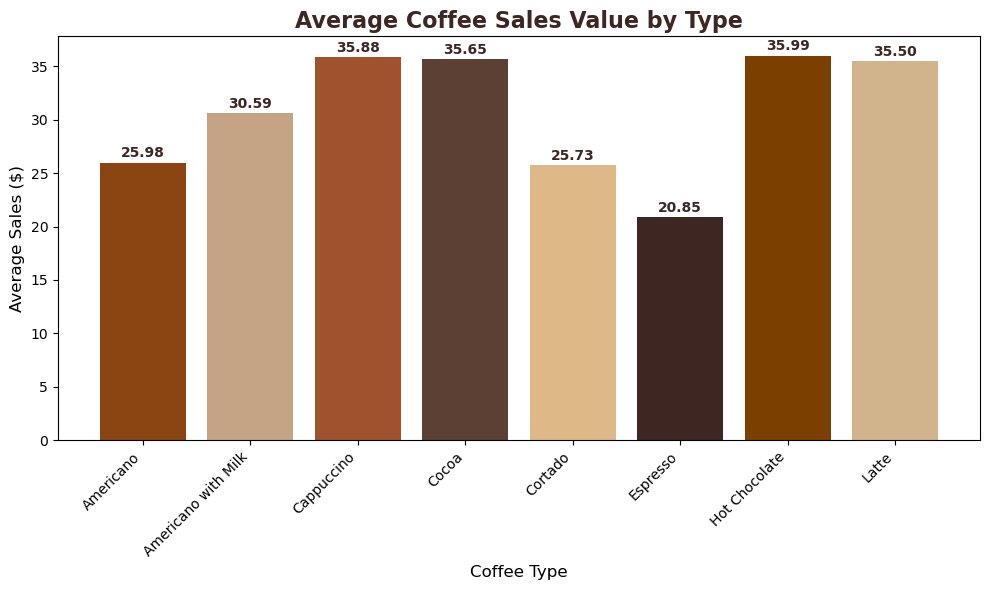

In [50]:
coffee_data = {
    'coffee_name': [
        'Americano', 'Americano with Milk', 'Cappuccino', 
        'Cocoa', 'Cortado', 'Espresso', 'Hot Chocolate', 'Latte'
    ],
    'mean_money': [
        25.975638, 30.594710, 35.883004,
        35.653389, 25.731220, 20.854884,
        35.990797, 35.502378
    ]
}

coffee_colors = [
    '#8B4513',  
    '#C4A484',  
    '#A0522D',  
    '#5C4033',  
    '#DEB887',  
    '#3E2723',  
    '#7B3F00',  
    '#D2B48C'   
]

plt.figure(figsize=(10,6))
bars = plt.bar(coffee_data['coffee_name'], coffee_data['mean_money'], color=coffee_colors) 
plt.title('Average Coffee Sales Value by Type', fontsize=16, fontweight='bold', color='#3E2723')
plt.xlabel('Coffee Type', fontsize=12)
plt.ylabel('Average Sales ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f'{yval:.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='#3E2723')

plt.tight_layout()

plt.savefig("plot.png", dpi=300, bbox_inches='tight')
plt.show()


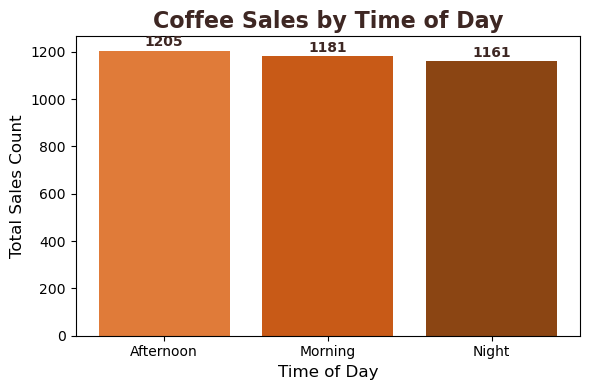

In [51]:

time_sales = df['Time_of_Day'].value_counts()

colors = ['#E07B39', '#C85A17', '#8B4513']  

plt.figure(figsize=(6,4))
bars = plt.bar(time_sales.index, time_sales.values, color=colors)
plt.title('Coffee Sales by Time of Day', fontsize=16, fontweight='bold', color='#3E2723')
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Total Sales Count', fontsize=12)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, yval, 
             ha='center', va='bottom', fontsize=10, fontweight='bold', color='#3E2723')

plt.tight_layout()
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
plt.show()


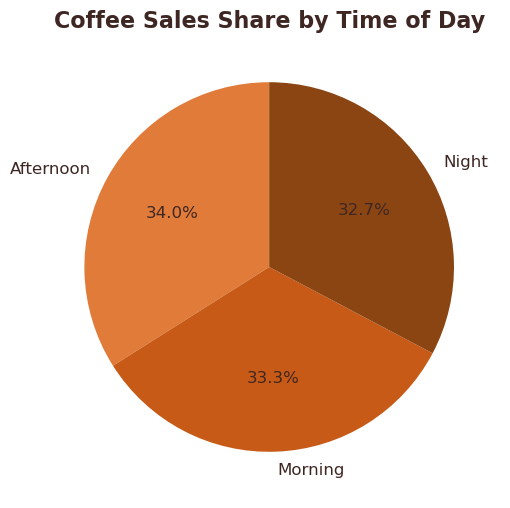

In [52]:
plt.figure(figsize=(6,6))
plt.pie(time_sales.values, labels=time_sales.index, autopct='%1.1f%%',
        startangle=90, colors=colors, textprops={'fontsize':12, 'color':'#3E2723'})
plt.title('Coffee Sales Share by Time of Day', fontsize=16, fontweight='bold', color='#3E2723')
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
plt.show()

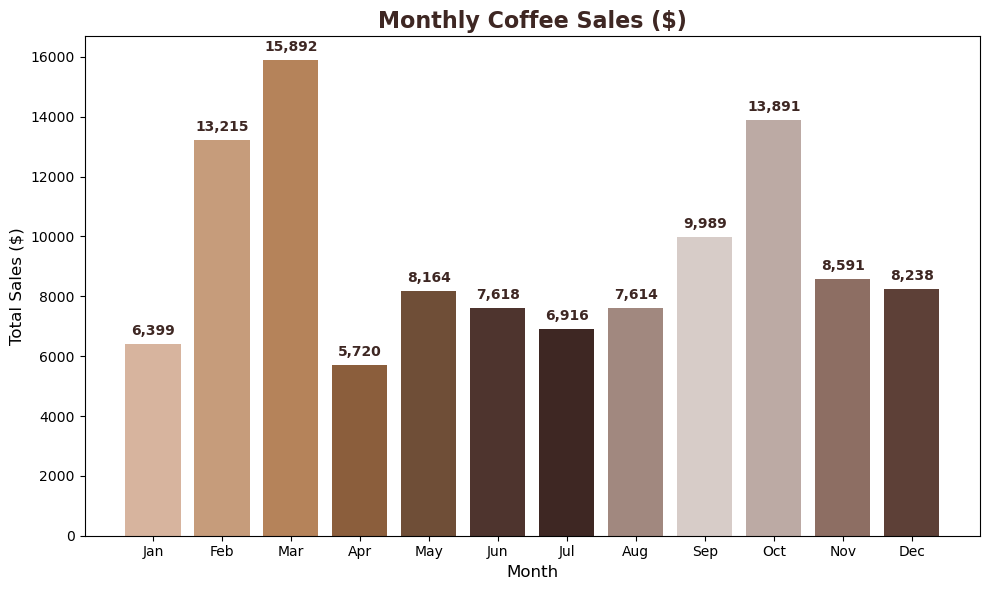

In [53]:
import matplotlib.pyplot as plt
coffee_colors = [
    '#D7B49E', '#C69C7B', '#B5835A', '#8B5E3C', 
    '#6F4E37', '#4E342E', '#3E2723', '#A1887F', 
    '#D7CCC8', '#BCAAA4', '#8D6E63', '#5D4037'
]

plt.figure(figsize=(10,6))
bars = plt.bar(month_of_sales['Month_name'], month_of_sales['money'], color=coffee_colors, edgecolor='none')
plt.title('Monthly Coffee Sales ($)', fontsize=16, fontweight='bold', color='#3E2723')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 200, f'{yval:,.0f}', 
             ha='center', va='bottom', fontsize=10, color='#3E2723', fontweight='bold')

plt.tight_layout()


plt.savefig("plot.png", dpi=300, bbox_inches='tight')
plt.show()


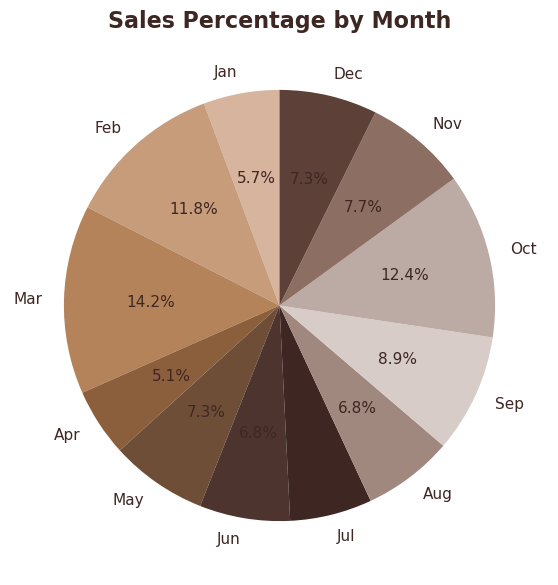

In [54]:
plt.figure(figsize=(7,7))
plt.pie(
    month_of_sales['percentage'], 
    labels=month_of_sales['Month_name'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=coffee_colors, 
    textprops={'fontsize':11, 'color':'#3E2723'}
)
plt.title('Sales Percentage by Month', fontsize=16, fontweight='bold', color='#3E2723')



plt.savefig("plot.png", dpi=300, bbox_inches='tight')
plt.show()

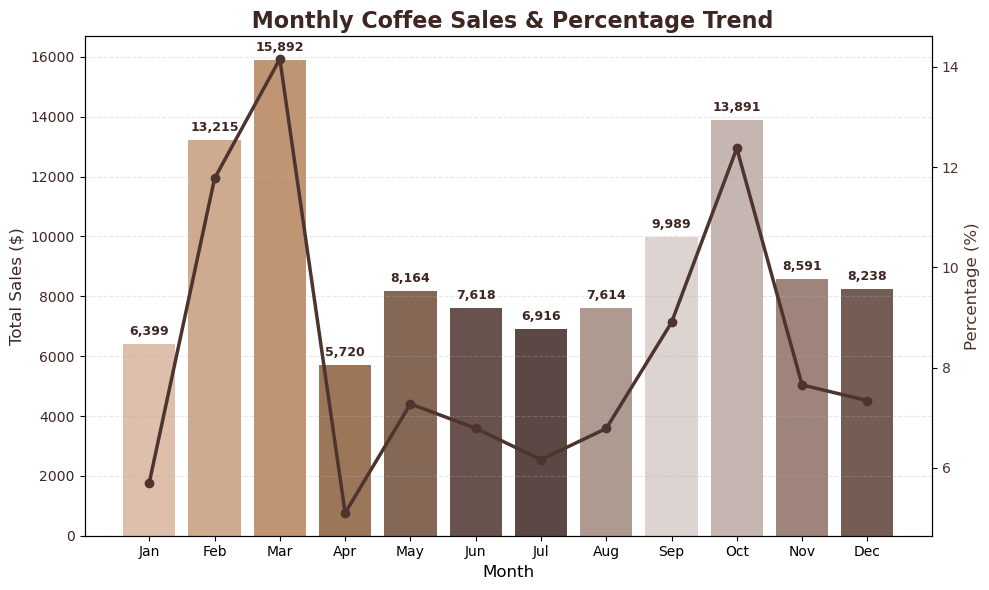

In [55]:
import matplotlib.pyplot as plt

coffee_colors = [
    '#D7B49E', '#C69C7B', '#B5835A', '#8B5E3C',
    '#6F4E37', '#4E342E', '#3E2723', '#A1887F',
    '#D7CCC8', '#BCAAA4', '#8D6E63', '#5D4037'
]

fig, ax1 = plt.subplots(figsize=(10,6))

bars = ax1.bar(
    month_of_sales['Month_name'], 
    month_of_sales['money'], 
    color=coffee_colors, 
    edgecolor='none', 
    alpha=0.85, 
    label='Total Sales ($)'
)

ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Total Sales ($)', color='#3E2723', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#3E2723')
ax1.grid(axis='y', linestyle='--', alpha=0.3) 
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 200, f'{yval:,.0f}', 
             ha='center', va='bottom', fontsize=9, color='#3E2723', fontweight='bold')

ax2 = ax1.twinx()  
ax2.plot(
    month_of_sales['Month_name'], 
    month_of_sales['percentage'], 
    color='#4E342E', 
    marker='o', 
    linewidth=2.5, 
    label='Percentage (%)'
)
ax2.set_ylabel('Percentage (%)', color='#4E342E', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#4E342E')

plt.title(' Monthly Coffee Sales & Percentage Trend', fontsize=16, fontweight='bold', color='#3E2723')
fig.tight_layout()



plt.savefig("plot.png", dpi=300, bbox_inches='tight')
plt.show()

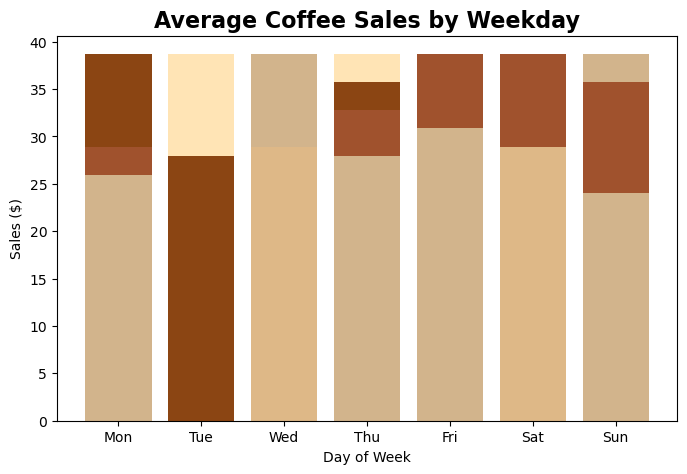

In [56]:
plt.figure(figsize=(8,5))
plt.bar(df['Weekday'], df['money'], color=['#FFD700', '#CD853F', '#8B4513', '#A0522D', '#D2B48C', '#DEB887', '#FFE4B5'])
plt.title('Average Coffee Sales by Weekday', fontsize=16, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Sales ($)')
plt.show()

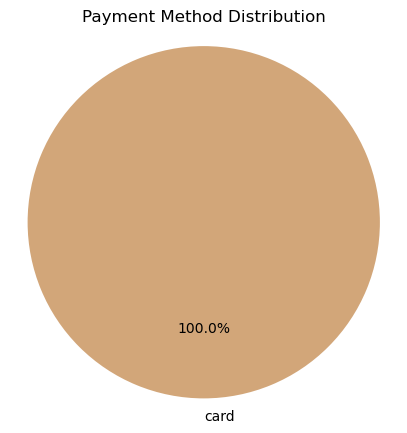

In [57]:
# Count payment methods
payment_counts = df['cash_type'].value_counts()

# Plot pie chart
plt.figure(figsize=(5,5))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90, colors=['#D2A679'])
plt.title('Payment Method Distribution')
plt.axis('equal')  # Make it a perfect circle
plt.show()

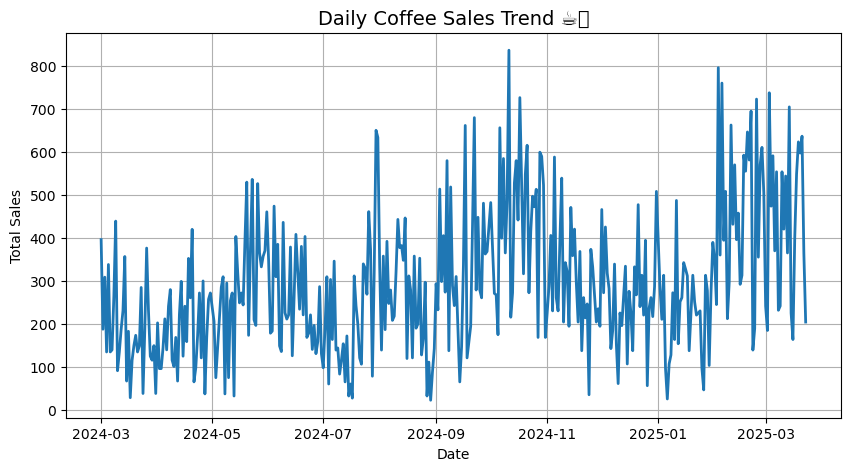

In [58]:
daily_sales = df.groupby('Date')['money'].sum().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=daily_sales, x='Date', y='money', linewidth=2)
plt.title('Daily Coffee Sales Trend ☕📈', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

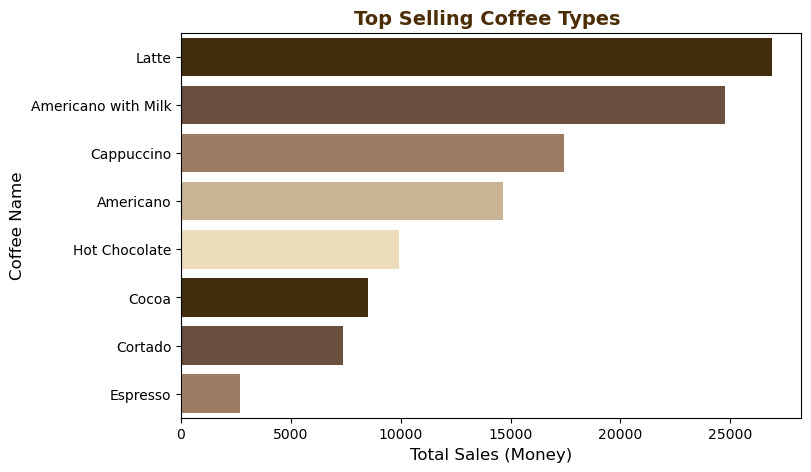

In [59]:
top_products = df.groupby('coffee_name')['money'].sum().reset_index().sort_values('money', ascending=False)

plt.figure(figsize=(8,5))

coffee_palette = ['#4B2E05', '#6F4E37', '#A67B5B', '#D2B48C', '#F5DEB3']

sns.barplot(
    data=top_products,
    x='money', y='coffee_name',
    palette=coffee_palette
)

plt.title('Top Selling Coffee Types ', fontsize=14, fontweight='bold', color='#4B2E05')
plt.xlabel('Total Sales (Money)', fontsize=12)
plt.ylabel('Coffee Name', fontsize=12)


plt.savefig("plot.png", dpi=300, bbox_inches='tight')
plt.show()

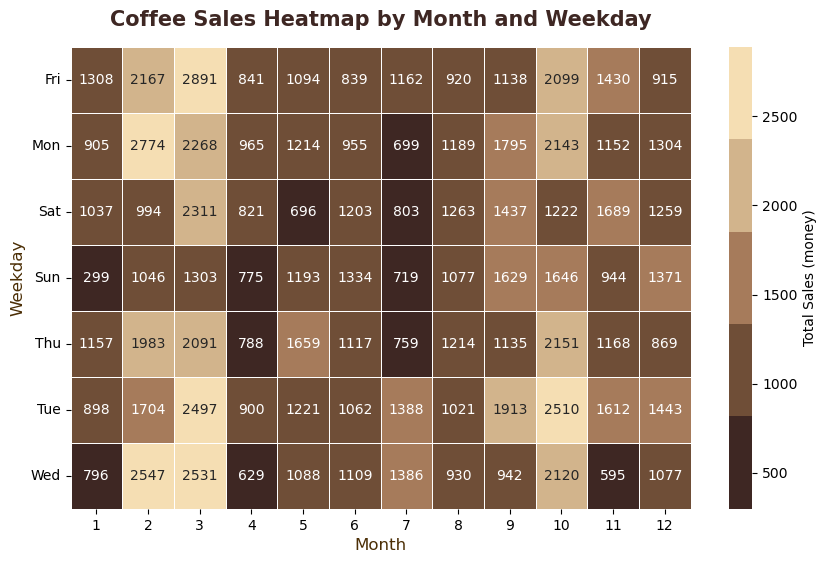

In [60]:
heatmap_data = df.pivot_table(
    values='money',
    index='Weekday',
    columns='Monthsort',  
    aggfunc='sum'
)

plt.figure(figsize=(10,6))
coffee_cmap = sns.color_palette(['#3e2723', '#6f4e37', '#a67b5b', '#d2b48c', '#f5deb3'])

sns.heatmap(
    heatmap_data,
    cmap=coffee_cmap,
    annot=True, fmt='.0f',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Total Sales (money)'}
)

plt.title('Coffee Sales Heatmap by Month and Weekday', fontsize=15, fontweight='bold', color='#3e2723', pad=15)
plt.xlabel('Month', fontsize=12, color='#4B2E05')
plt.ylabel('Weekday', fontsize=12, color='#4B2E05')

plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

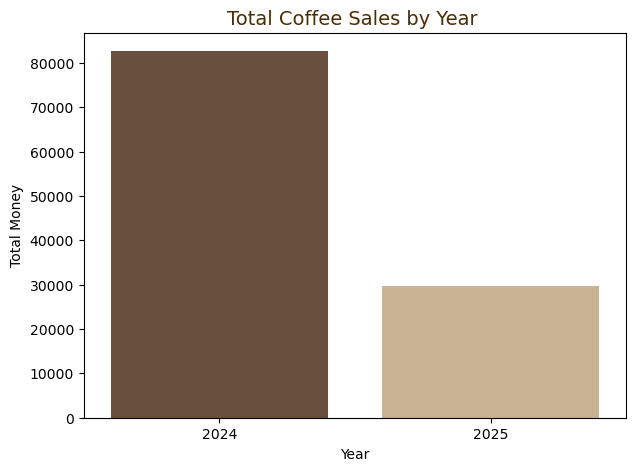

In [61]:
year_sales = df.groupby('Year')['money'].sum().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(data=year_sales, x='Year', y='money', palette=['#6F4E37', '#D2B48C'])
plt.title('Total Coffee Sales by Year ', fontsize=14, color='#4B2E05')
plt.xlabel('Year')
plt.ylabel('Total Money')

plt.savefig("plot.png", dpi=300, bbox_inches='tight')
plt.show()

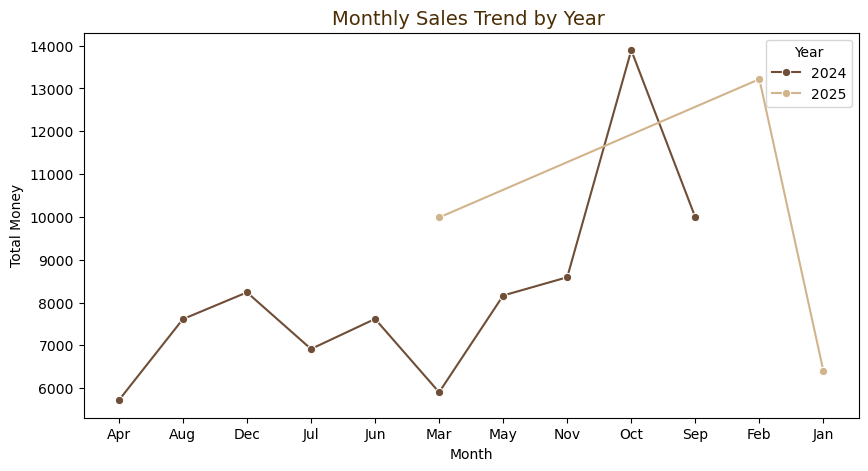

In [62]:
monthly_sales = df.groupby(['Year', 'Month_name'])['money'].sum().reset_index()
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales, x='Month_name', y='money', hue='Year', marker='o', palette=['#6F4E37', '#D2B48C'])
plt.title('Monthly Sales Trend by Year ', fontsize=14, color='#4B2E05')
plt.xlabel('Month')
plt.ylabel('Total Money')
plt.legend(title='Year')
plt.savefig("plot.png", dpi=300, bbox_inches='tight')
plt.show()


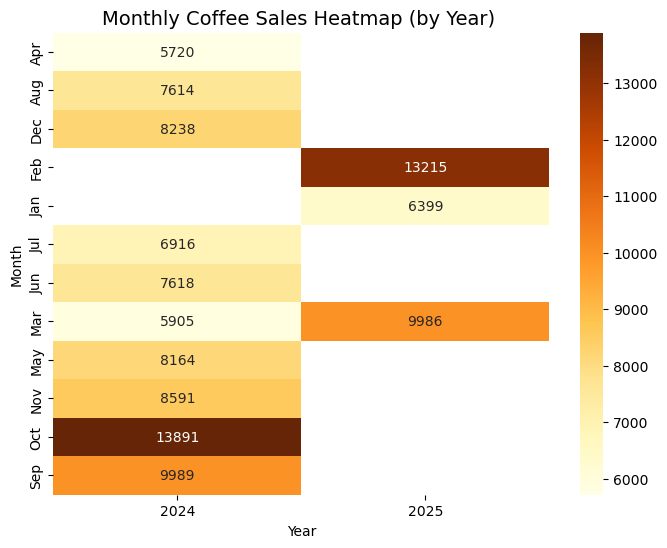

In [63]:
heatmap_data = df.pivot_table(values='money', index='Month_name', columns='Year', aggfunc='sum')

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, cmap='YlOrBr', annot=True, fmt='.0f')
plt.title('Monthly Coffee Sales Heatmap (by Year) ', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Month')
plt.show()

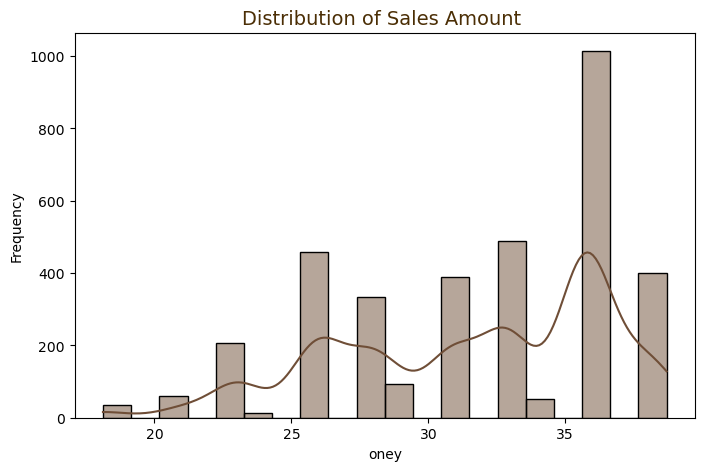

In [64]:
plt.figure(figsize=(8,5))
sns.histplot(df['money'], bins=20, color='#6F4E37', kde=True)
plt.title('Distribution of Sales Amount ', fontsize=14, color='#4B2E05')
plt.xlabel('oney')
plt.ylabel('Frequency')


plt.savefig("plot.png", dpi=300, bbox_inches='tight')
plt.show()

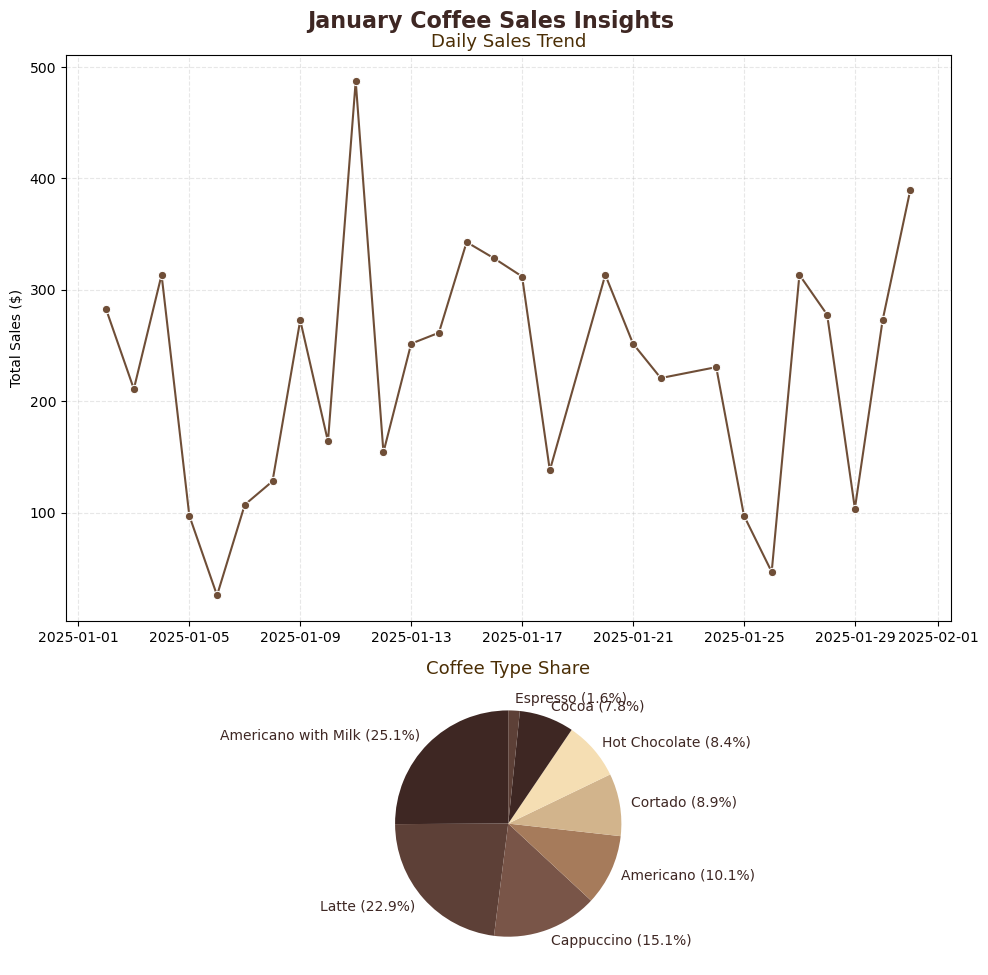

*January Summary:*
- The best-selling coffee this month was *Americano with Milk, contributing **25.1%* of total sales.
- Average daily sales reached *$228.53, with the peak on **January 11 ($487)*.
- Overall, January showed strong demand consistency across most coffee types.



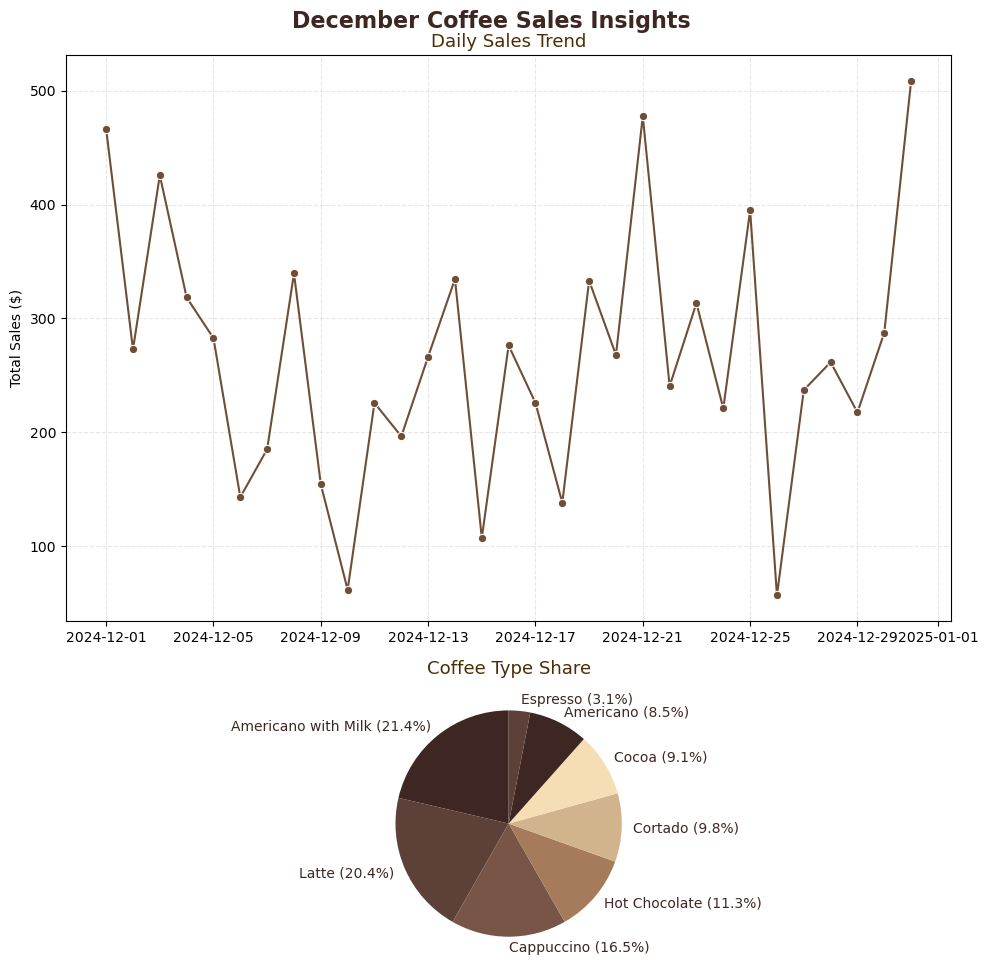

*December Summary:*
- The best-selling coffee this month was *Americano with Milk, contributing **21.4%* of total sales.
- Average daily sales reached *$265.73, with the peak on **December 31 ($508)*.
- Overall, December showed strong demand consistency across most coffee types.



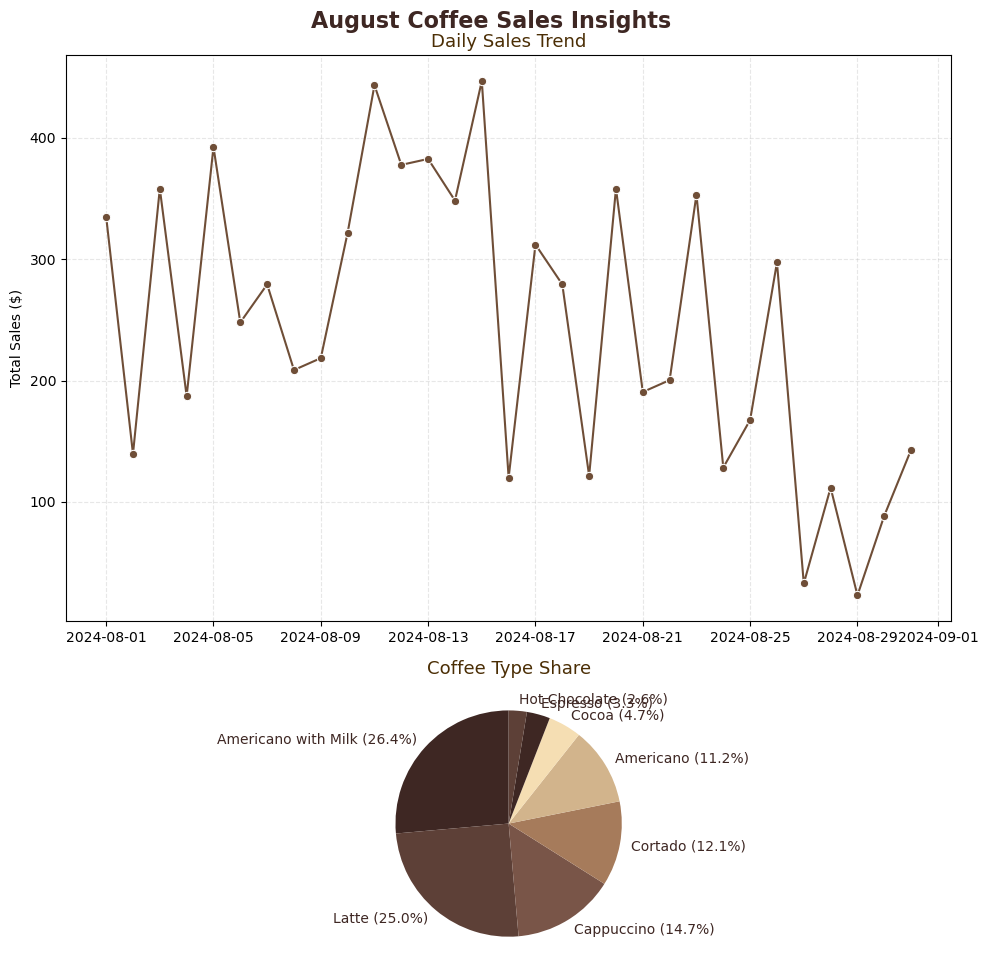

*August Summary:*
- The best-selling coffee this month was *Americano with Milk, contributing **26.4%* of total sales.
- Average daily sales reached *$245.61, with the peak on **August 15 ($446)*.
- Overall, August showed strong demand consistency across most coffee types.



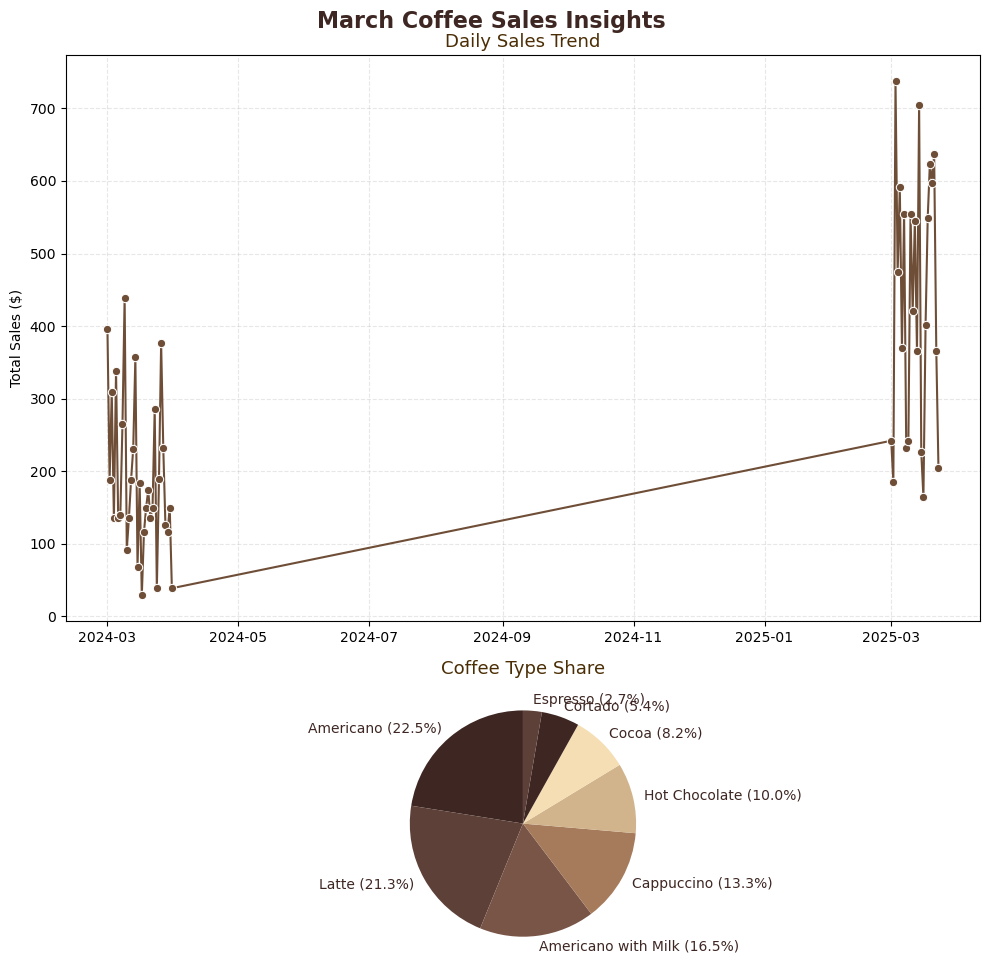

*March Summary:*
- The best-selling coffee this month was *Americano, contributing **22.5%* of total sales.
- Average daily sales reached *$294.29, with the peak on **March 03 ($737)*.
- Overall, March showed strong demand consistency across most coffee types.



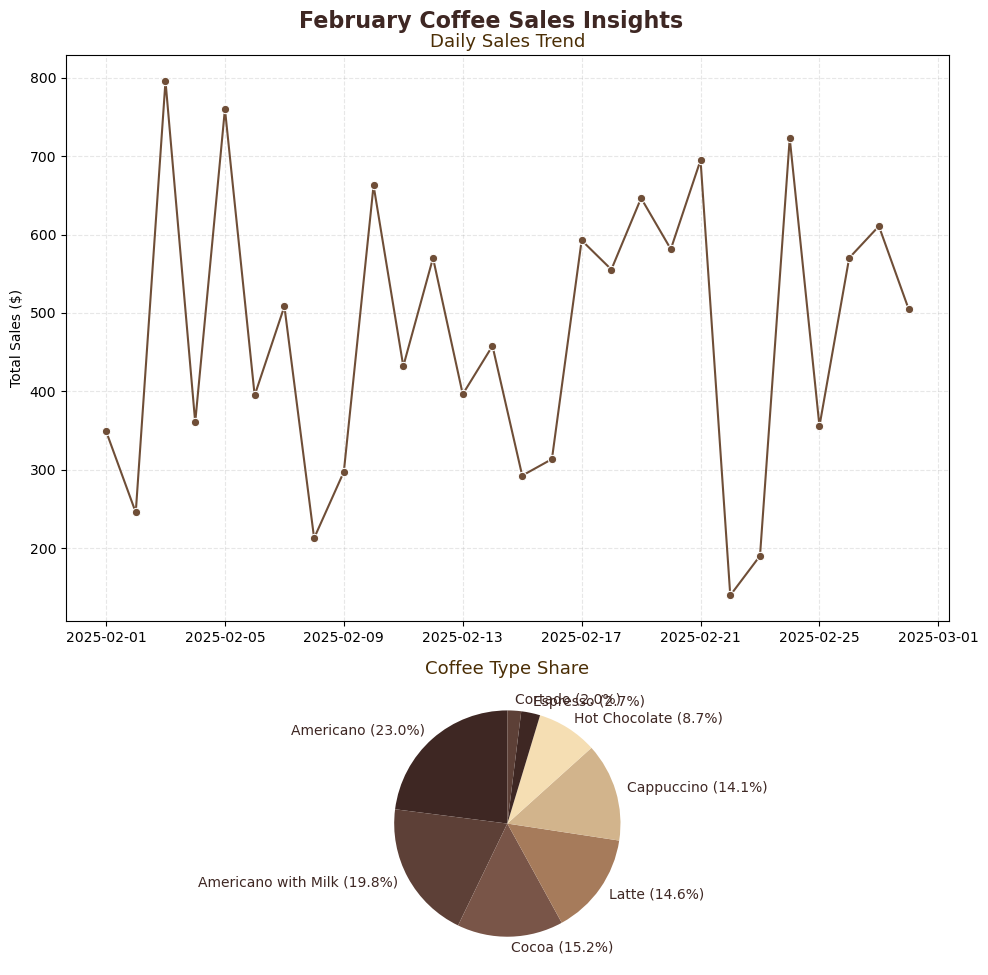

*February Summary:*
- The best-selling coffee this month was *Americano, contributing **23.0%* of total sales.
- Average daily sales reached *$471.98, with the peak on **February 03 ($796)*.
- Overall, February showed strong demand consistency across most coffee types.



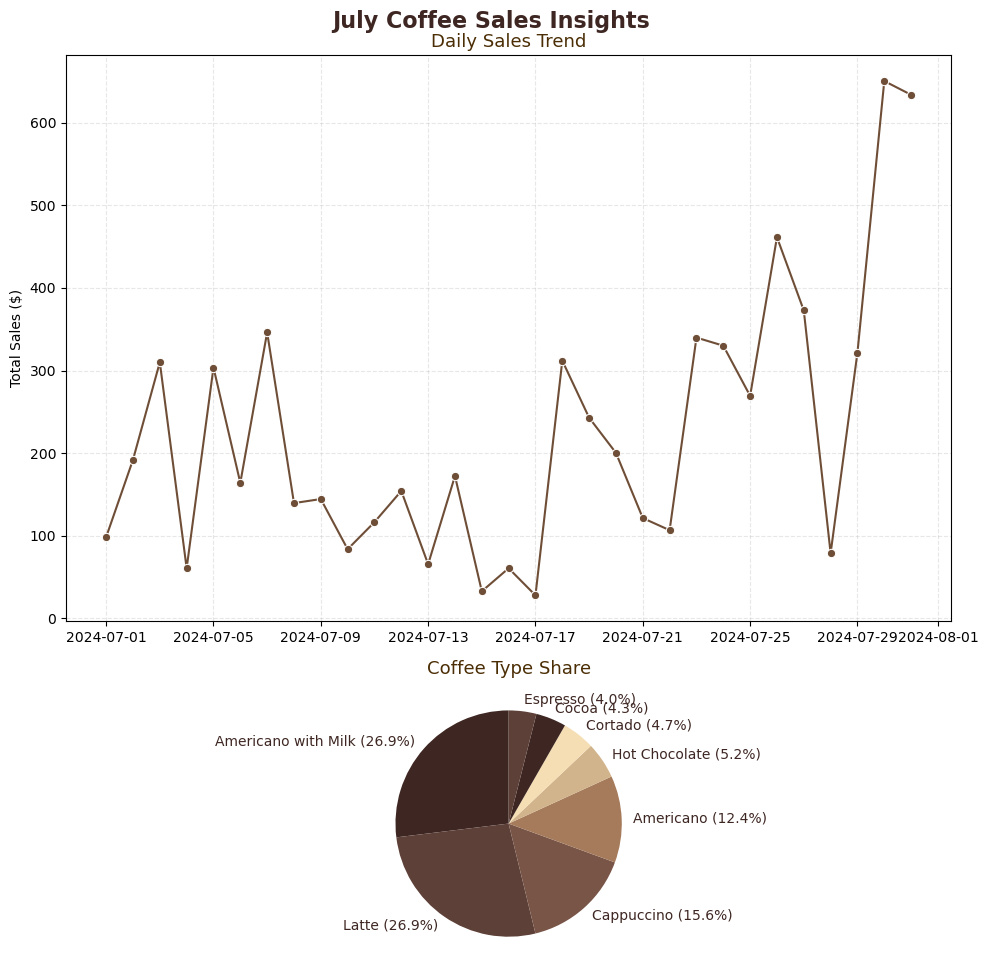

*July Summary:*
- The best-selling coffee this month was *Americano with Milk, contributing **26.9%* of total sales.
- Average daily sales reached *$223.09, with the peak on **July 30 ($650)*.
- Overall, July showed strong demand consistency across most coffee types.



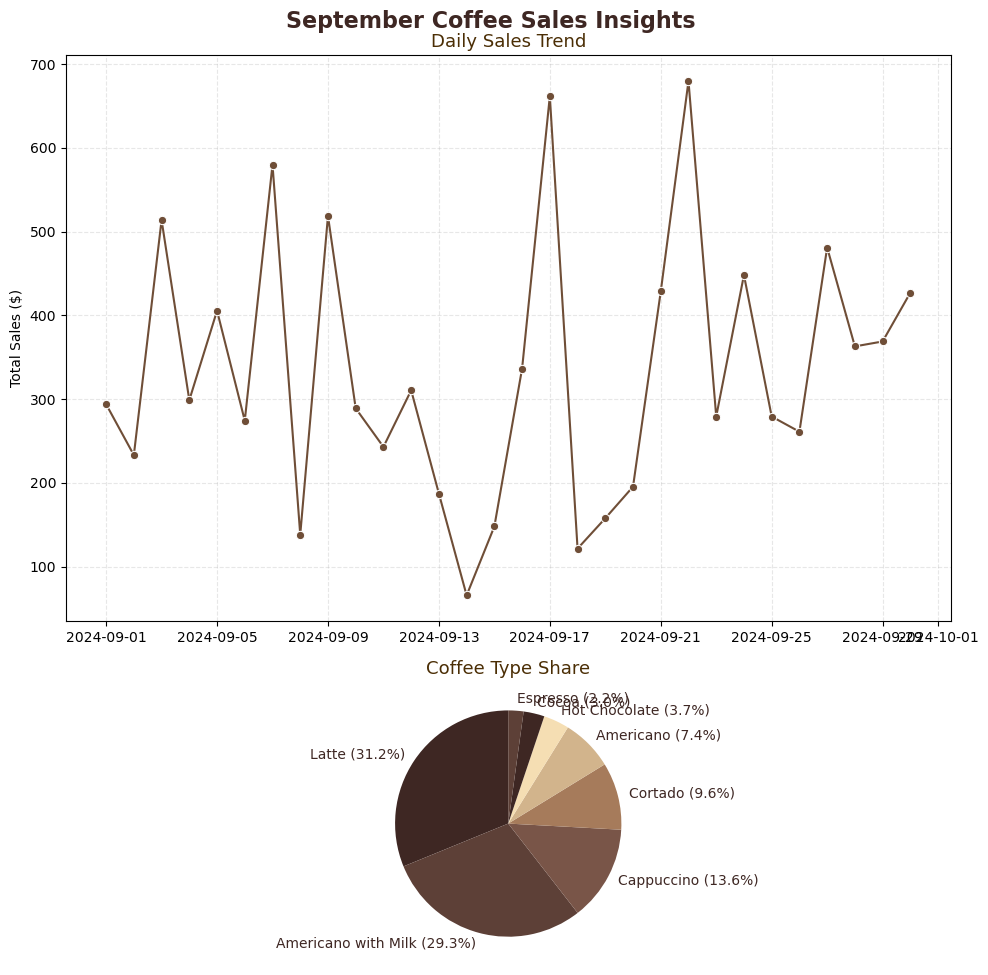

*September Summary:*
- The best-selling coffee this month was *Latte, contributing **31.2%* of total sales.
- Average daily sales reached *$332.95, with the peak on **September 22 ($679)*.
- Overall, September showed strong demand consistency across most coffee types.



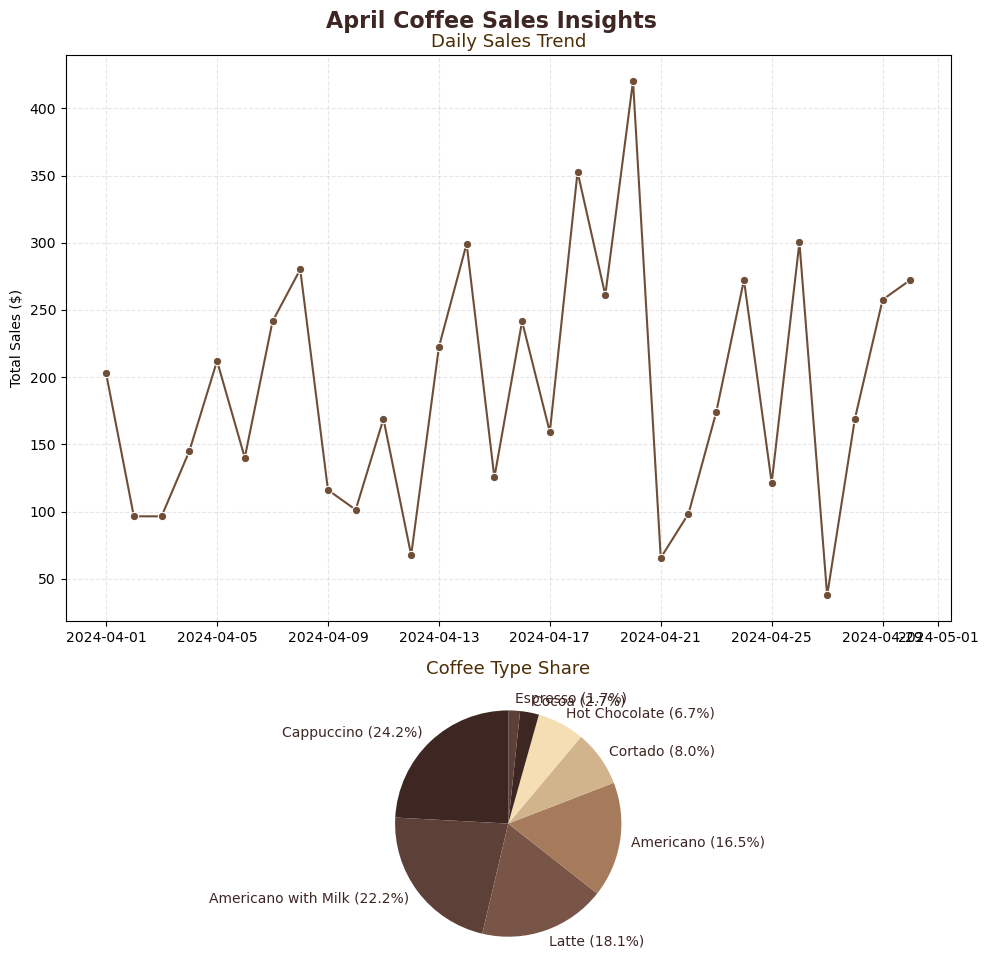

*April Summary:*
- The best-selling coffee this month was *Cappuccino, contributing **24.2%* of total sales.
- Average daily sales reached *$190.65, with the peak on **April 20 ($420)*.
- Overall, April showed strong demand consistency across most coffee types.



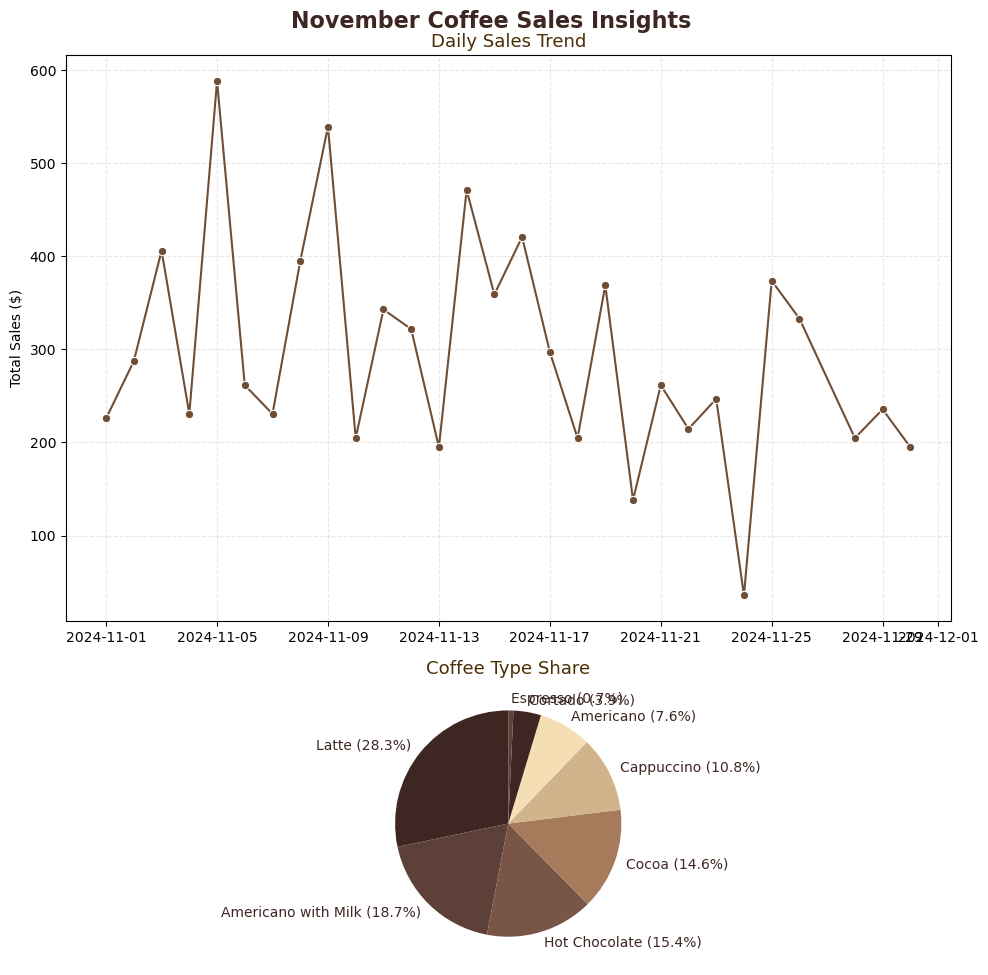

*November Summary:*
- The best-selling coffee this month was *Latte, contributing **28.3%* of total sales.
- Average daily sales reached *$296.23, with the peak on **November 05 ($588)*.
- Overall, November showed strong demand consistency across most coffee types.



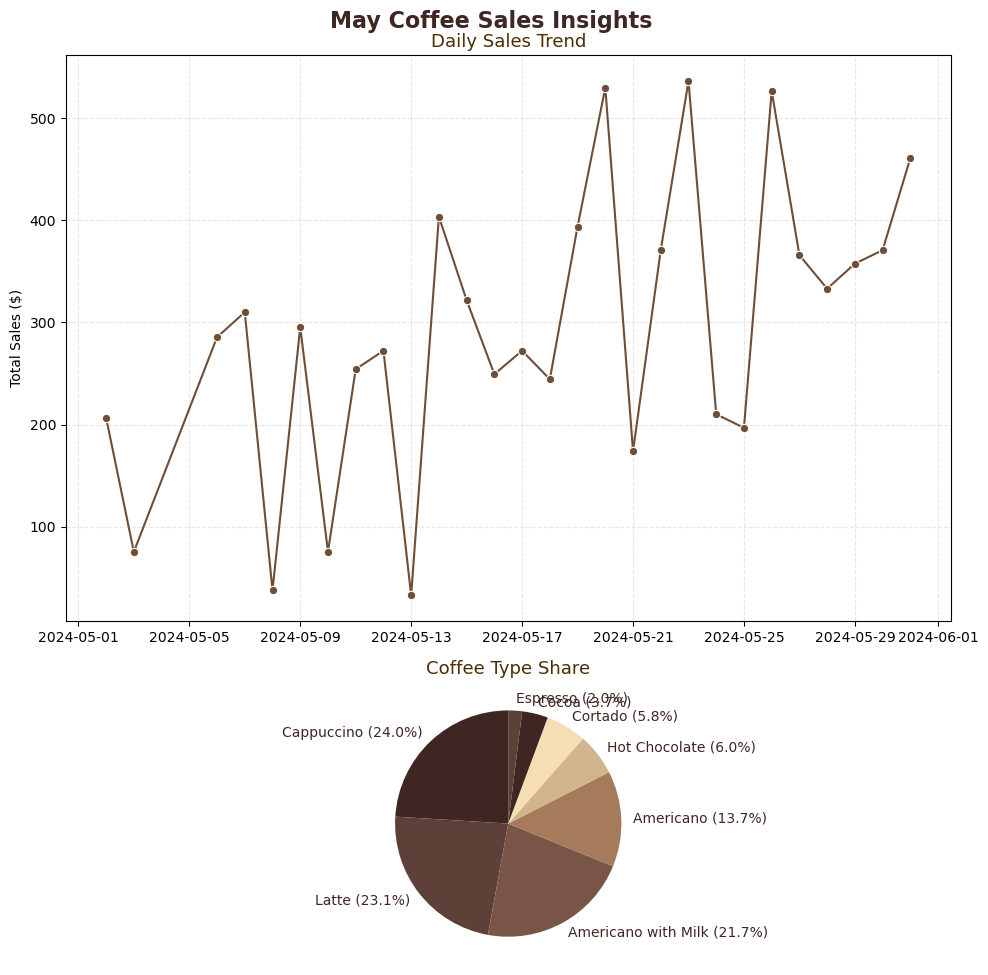

*May Summary:*
- The best-selling coffee this month was *Cappuccino, contributing **24.0%* of total sales.
- Average daily sales reached *$291.59, with the peak on **May 23 ($536)*.
- Overall, May showed strong demand consistency across most coffee types.



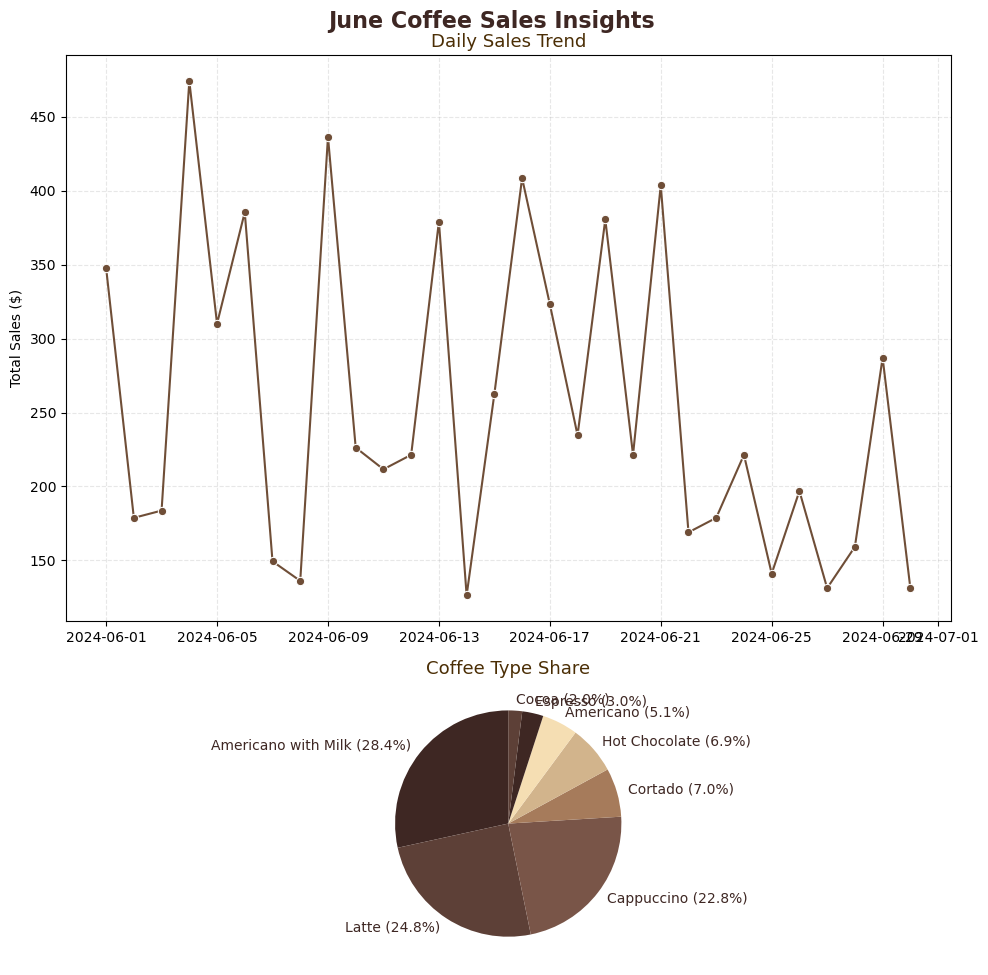

*June Summary:*
- The best-selling coffee this month was *Americano with Milk, contributing **28.4%* of total sales.
- Average daily sales reached *$253.93, with the peak on **June 04 ($474)*.
- Overall, June showed strong demand consistency across most coffee types.



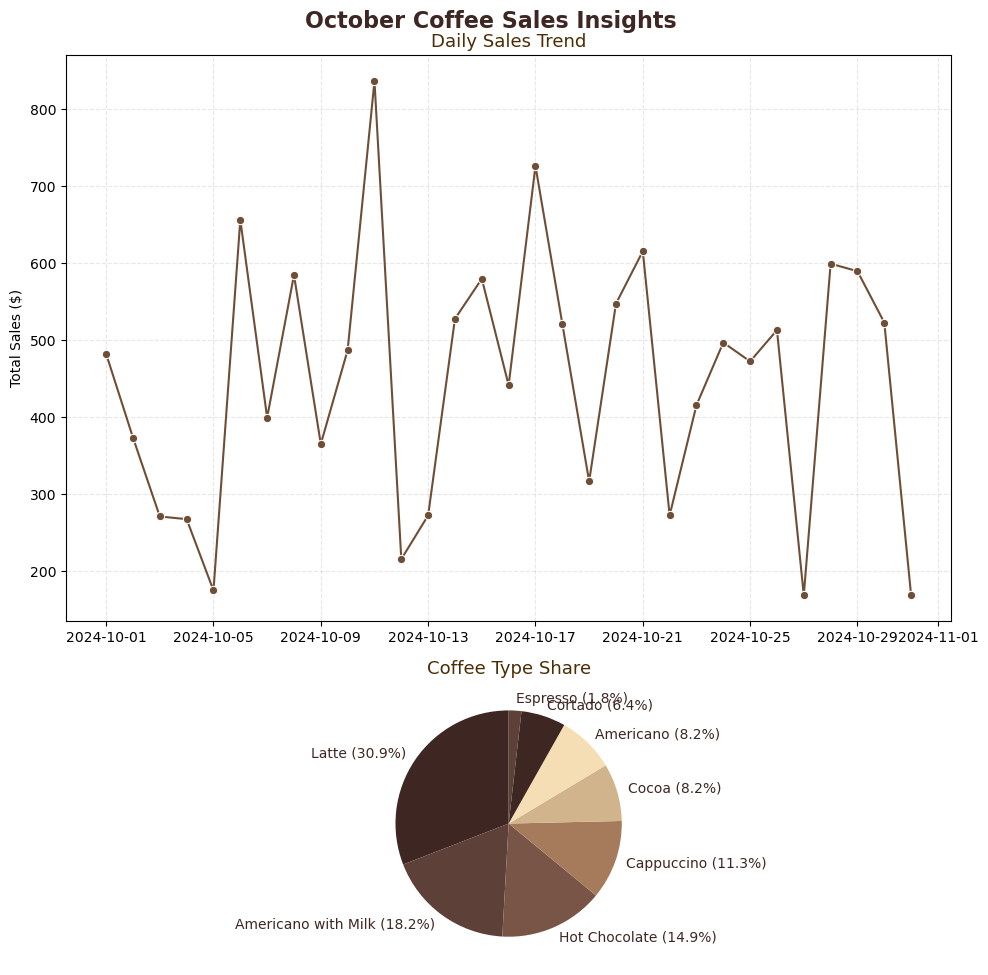

*October Summary:*
- The best-selling coffee this month was *Latte, contributing **30.9%* of total sales.
- Average daily sales reached *$448.1, with the peak on **October 11 ($836)*.
- Overall, October showed strong demand consistency across most coffee types.



In [65]:

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month_name'] = df['Date'].dt.month_name()

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df['Month_name'] = pd.Categorical(df['Month_name'], categories=month_order, ordered=True)

months = df['Month_name'].dropna().unique()

coffee_colors = ['#3E2723', '#5D4037', '#795548', '#A67B5B', '#D2B48C', '#F5DEB3']

for month in months:
    monthly_data = df[df['Month_name'] == month]
    
    top_coffee = (
        monthly_data.groupby('coffee_name')['money']
        .sum().reset_index()
        .sort_values('money', ascending=False)
    )
    total_month_sales = top_coffee['money'].sum()
    top_coffee['Share (%)'] = round((top_coffee['money'] / total_month_sales) * 100, 1)
    
    daily_sales = (
        monthly_data.groupby('Date')['money']
        .sum().reset_index()
    )
    top_day = daily_sales.loc[daily_sales['money'].idxmax()]
    avg_sales = round(daily_sales['money'].mean(), 2)
    
    fig, axes = plt.subplots(2, 1, figsize=(10,10), gridspec_kw={'height_ratios': [2,1]})
    fig.suptitle(f"{month} Coffee Sales Insights ", fontsize=16, color='#3E2723', fontweight='bold', y=0.97)
    
    sns.lineplot(data=daily_sales, x='Date', y='money', marker='o', color='#6F4E37', ax=axes[0])
    axes[0].set_title('Daily Sales Trend', fontsize=13, color='#4B2E05')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('Total Sales ($)')
    axes[0].grid(True, linestyle='--', alpha=0.3)
    
    axes[1].pie(
        top_coffee['money'],
        labels=[f"{n} ({p}%)" for n, p in zip(top_coffee['coffee_name'], top_coffee['Share (%)'])],
        colors=coffee_colors,
        startangle=90,
        textprops={'fontsize': 10, 'color': '#3E2723'}
    )
    axes[1].set_title('Coffee Type Share', fontsize=13, color='#4B2E05')
    
    plt.tight_layout()
    plt.show()
    
    top_type = top_coffee.iloc[0]['coffee_name']
    top_share = top_coffee.iloc[0]['Share (%)']
    top_date = top_day['Date'].strftime('%B %d')
    top_value = int(top_day['money'])
    
    print(f"*{month} Summary:*")
    print(f"- The best-selling coffee this month was *{top_type}, contributing **{top_share}%* of total sales.")
    print(f"- Average daily sales reached *${avg_sales}, with the peak on **{top_date} (${top_value})*.")
    print(f"- Overall, {month} showed strong demand consistency across most coffee types.\n")